# Linear Regression: Concepts, Implementation, and Visualization

This notebook provides a comprehensive overview of linear regression, including mathematical intuition, code implementations (from scratch), and visualization. Each code cell is preceded by a clear explanation, and variable names are chosen for clarity and readability.

## What is Linear Regression?

Linear regression is a fundamental statistical technique used to model the relationship between a dependent variable (target) and one or more independent variables (features). The goal is to find the best-fitting straight line (in simple linear regression) or hyperplane (in multiple linear regression) that predicts the target variable from the features.

**Simple Linear Regression Equation:**

$y = w x + b$

- $y$: Target variable
- $x$: Feature (input variable)
- $w$: Slope (weight)
- $b$: Intercept (bias)

The optimal values of $w$ and $b$ are found by minimizing the sum of squared errors (SSE) between the predicted and actual values.

**Multiple Linear Regression Equation:**

$y = w_0 + w_1 x_1 + w_2 x_2 + ... + w_n x_n$

where $w_0$ is the intercept and $w_1, ..., w_n$ are the weights for each feature.

### Simple Linear Regression: Least Squares Method

Let's implement simple linear regression from scratch using the least squares method. We'll use clear variable names and validate inputs for robustness.

In [1]:
import numpy as np

class SimpleLinearRegression:
    def __init__(self):
        self.slope = None  # Weight (w)
        self.intercept = None  # Bias (b)

    def fit(self, features, targets):
        # Input validation
        if len(features) != len(targets):
            raise ValueError("Features and targets must have the same length.")
        if len(features) == 0:
            raise ValueError("Input arrays must not be empty.")
        
        mean_x = np.mean(features)
        mean_y = np.mean(targets)
        numerator = np.sum((features - mean_x) * (targets - mean_y))
        denominator = np.sum((features - mean_x) ** 2)
        self.slope = numerator / denominator
        self.intercept = mean_y - self.slope * mean_x

    def predict(self, features):
        return self.slope * features + self.intercept

In [2]:
# Example usage of SimpleLinearRegression
# Let's fit a line to some sample data and make predictions.

X_sample = np.array([1, 2, 3, 4, 5])
y_sample = np.array([2, 4, 5, 4, 5])

model = SimpleLinearRegression()
model.fit(X_sample, y_sample)

print("Slope (w):", model.slope)
print("Intercept (b):", model.intercept)

predictions = model.predict(X_sample)
print("Predictions:", predictions)

Slope (w): 0.6
Intercept (b): 2.2
Predictions: [2.8 3.4 4.  4.6 5.2]


### Vectorized Linear Regression (Normal Equation)

Now, let's implement linear regression using the normal equation, which is a vectorized approach suitable for multiple features. This method directly computes the optimal weights without iterative optimization.

**Normal Equation:**

$y = Xw$

$w = (X^T X)^{-1} X^T y$

Here, $X$ is the feature matrix (with a bias column), $w$ is the weight vector, and $y$ is the target vector.

In [3]:
import numpy as np

class VectorizedLinearRegression:
    def __init__(self):
        self.weights = None  # Includes bias as the first element

    def fit(self, features, targets):
        # Ensure features is 2D
        if features.ndim == 1:
            features = features.reshape(-1, 1)
        n_samples = features.shape[0]
        # Add bias column (ones) to features
        X_bias = np.hstack([np.ones((n_samples, 1)), features])
        # Normal equation
        self.weights = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ targets

    def predict(self, features):
        if features.ndim == 1:
            features = features.reshape(-1, 1)
        n_samples = features.shape[0]
        X_bias = np.hstack([np.ones((n_samples, 1)), features])
        return X_bias @ self.weights

In [4]:
# Example usage of VectorizedLinearRegression
# Fit a model to 2D data and make predictions.

X_multi = np.array([[2, 2], [4, 5], [7, 8]])
y_multi = np.array([9, 17, 26])

vector_model = VectorizedLinearRegression()
vector_model.fit(X_multi, y_multi)

print("Weights (including bias):", vector_model.weights)

X_new = np.array([[10, 11], [13, 14]])
predictions_new = vector_model.predict(X_new)
print("Predictions for new data:", predictions_new)

Weights (including bias): [3. 1. 2.]
Predictions for new data: [35. 44.]


### Linear Regression via Gradient Descent

For large datasets, the normal equation can be computationally expensive. Gradient descent is an iterative optimization algorithm that updates the weights to minimize the mean squared error (MSE) loss.

**Prediction function:**

$\hat{y} = w x + b$

**Loss function (MSE):**

$J(w, b) = \frac{1}{N} \sum_{i=1}^{N} (y_i - (w x_i + b))^2$

**Gradients:**

$\frac{\partial J}{\partial w} = -\frac{2}{N} \sum_{i=1}^N x_i (y_i - (w x_i + b))$

$\frac{\partial J}{\partial b} = -\frac{2}{N} \sum_{i=1}^N (y_i - (w x_i + b))$

**Gradient descent update:**

$w := w - \alpha \cdot \frac{\partial J}{\partial w}$

$b := b - \alpha \cdot \frac{\partial J}{\partial b}$

### Improving the Implementation

Let's enhance our linear regression implementation with:

1. **Input validation**: Ensure features and targets are compatible and not empty.
2. **Vectorized operations**: Use NumPy for efficient computation.
3. **L2 Regularization**: Add a penalty to the weights to prevent overfitting.
4. **Gradient Descent**: Use iterative optimization for large datasets.

Below is an improved implementation using gradient descent and regularization.

In [5]:
import numpy as np

class LinearRegressionGD:
    def __init__(self, regularization_lambda=0.0, learning_rate=0.1, epochs=10000):
        self.regularization_lambda = regularization_lambda
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = 0.0

    def fit(self, features, targets):
        features = np.array(features)
        targets = np.array(targets)
        if features.ndim == 1:
            features = features.reshape(-1, 1)
        n_samples, n_features = features.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        for _ in range(self.epochs):
            predictions = features @ self.weights + self.bias
            loss = 1/ n_samples * np.sum((predictions -features)**2)
            errors = predictions - targets
            # Compute gradients
            grad_weights = (2 / n_samples) * (features.T @ errors) + 2 * self.regularization_lambda * self.weights
            grad_bias = (2 / n_samples) * np.sum(errors)
            # Update parameters
            self.weights -= self.learning_rate * grad_weights
            self.bias -= self.learning_rate * grad_bias

    def predict(self, features):
        features = np.array(features)
        if features.ndim == 1:
            features = features.reshape(-1, 1)
        return features @ self.weights + self.bias

In [6]:
# Example usage of LinearRegressionGD (Gradient Descent)
# Fit the model and print weights, bias, and predictions.

X_gd = np.array([1, 2, 3, 4, 5])
y_gd = np.array([2, 4, 5, 4, 5])

gd_model = LinearRegressionGD(regularization_lambda=0.1, learning_rate=0.01, epochs=10000)
gd_model.fit(X_gd, y_gd)

y_gd_pred = gd_model.predict(X_gd)

print("Weights:", gd_model.weights)
print("Bias:", gd_model.bias)
print("Predictions:", y_gd_pred)

Weights: [0.57142857]
Bias: 2.2857142857142243
Predictions: [2.85714286 3.42857143 4.         4.57142857 5.14285714]


## Visualizing Linear Regression Results

Let's plot the original data points and the fitted regression line to visually assess the model's performance.

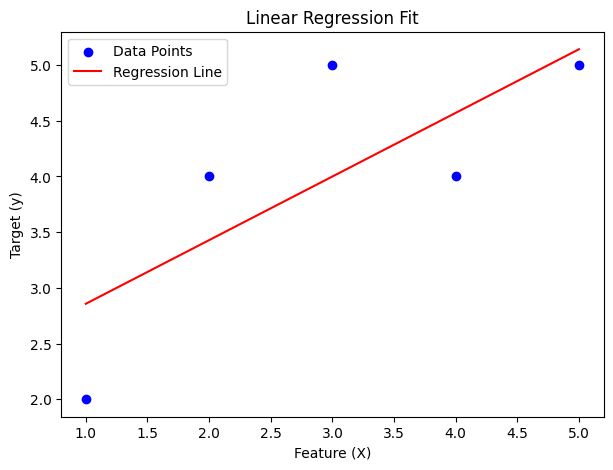

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(X_gd, y_gd, color='blue', label='Data Points')
plt.plot(X_gd, y_gd_pred, color='red', label='Regression Line')
plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.title('Linear Regression Fit')
plt.legend()
plt.show()